In [1]:
# ============================================================
# 08 NOISE ROBUSTNESS SWEEP
# CELL 1 — ENVIRONMENT & PATHS
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, transpile
from qiskit.circuit import ParameterVector

from qiskit_aer import AerSimulator
from qiskit_aer.noise import (
    NoiseModel,
    pauli_error,
    depolarizing_error,
    ReadoutError
)

# ------------------------------------------------------------
# PROJECT PATHS
# ------------------------------------------------------------

PROJECT_DIR = Path(r"C:\Users\heart\quantum_6g_ai")
RESULTS_DIR = PROJECT_DIR / "results"
FIGURES_DIR = RESULTS_DIR / "figures"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("=" * 60)
print("08 NOISE ROBUSTNESS SWEEP")
print("=" * 60)

print("Project :", PROJECT_DIR)
print("Results :", RESULTS_DIR)
print("Figures :", FIGURES_DIR)

assert PROJECT_DIR.exists()
assert RESULTS_DIR.exists()
assert FIGURES_DIR.exists()

print("\nValidation: PASS")

08 NOISE ROBUSTNESS SWEEP
Project : C:\Users\heart\quantum_6g_ai
Results : C:\Users\heart\quantum_6g_ai\results
Figures : C:\Users\heart\quantum_6g_ai\results\figures

Validation: PASS


In [5]:
# ============================================================
# CELL 2 — LOAD FROZEN EXPERIMENT BASELINE
# FINAL FIX
# ============================================================

trained_theta = np.load(
    RESULTS_DIR / "trained_theta.npy"
)

test_data = pd.read_csv(
    RESULTS_DIR / "quantum_test_features.csv"
)

ideal_results = pd.read_csv(
    RESULTS_DIR / "ideal_results.csv"
)

# ------------------------------------------------------------
# TEST DATA
# ------------------------------------------------------------

X_test_q = test_data[
    [
        "Trust_Score",
        "Risk_Score",
        "Interference",
        "Resource_Load"
    ]
].to_numpy(dtype=float)

y_test = test_data[
    "Label"
].to_numpy(dtype=int)


# ------------------------------------------------------------
# IDEAL BASELINE
# Actual schema:
#
# True_Label
# Predicted_Label
# Probability_Class_1
# ------------------------------------------------------------

ideal_probabilities = ideal_results[
    "Probability_Class_1"
].to_numpy(dtype=float)

ideal_predictions = ideal_results[
    "Predicted_Label"
].to_numpy(dtype=int)


# ------------------------------------------------------------
# VALIDATION
# ------------------------------------------------------------

print("=" * 60)
print("08 NOISE ROBUSTNESS SWEEP")
print("BASELINE LOADED")
print("=" * 60)

print("Ideal results columns:")
print(list(ideal_results.columns))

print()

print("Test samples        :", len(X_test_q))
print("Quantum features    :", X_test_q.shape)
print("Labels              :", y_test.shape)
print("Trained parameters  :", trained_theta.shape)
print("Ideal probabilities :", ideal_probabilities.shape)
print("Ideal predictions   :", ideal_predictions.shape)

# ------------------------------------------------------------
# Shape checks
# ------------------------------------------------------------

assert X_test_q.shape == (200, 4)
assert y_test.shape == (200,)
assert trained_theta.shape == (16,)

assert ideal_probabilities.shape == (200,)
assert ideal_predictions.shape == (200,)

# ------------------------------------------------------------
# Probability checks
# ------------------------------------------------------------

assert np.all(
    (ideal_probabilities >= 0.0)
    &
    (ideal_probabilities <= 1.0)
)

# ------------------------------------------------------------
# Prediction checks
# ------------------------------------------------------------

assert np.all(
    np.isin(
        ideal_predictions,
        [0, 1]
    )
)

print("\nIdeal baseline accuracy:",
      np.mean(
          ideal_predictions == y_test
      ))

print("\nValidation: PASS")

08 NOISE ROBUSTNESS SWEEP
BASELINE LOADED
Ideal results columns:
['True_Label', 'Predicted_Label', 'Probability_Class_1']

Test samples        : 200
Quantum features    : (200, 4)
Labels              : (200,)
Trained parameters  : (16,)
Ideal probabilities : (200,)
Ideal predictions   : (200,)

Ideal baseline accuracy: 0.85

Validation: PASS


In [3]:
# ============================================================
# CELL 3 — VQC ARCHITECTURE
# ============================================================

N_QUBITS = 4
N_LAYERS = 2
N_PARAMS = N_QUBITS * 2 * N_LAYERS

VQC_PARAMS = ParameterVector(
    "theta_sweep",
    length=N_PARAMS
)

def build_vqc(x):
    """
    Build the same VQC architecture used in
    05 VQC Training, 06 Ideal Simulation,
    and 07 Noisy Simulation.
    """

    qc = QuantumCircuit(N_QUBITS)

    # --------------------------------------------------------
    # Feature encoding
    # --------------------------------------------------------

    for q in range(N_QUBITS):
        qc.ry(float(x[q]), q)
        qc.rz(float(x[q]), q)

    # --------------------------------------------------------
    # Feature-map entanglement
    # --------------------------------------------------------

    for q in range(N_QUBITS - 1):
        qc.cx(q, q + 1)

    # --------------------------------------------------------
    # Trainable VQC layers
    # --------------------------------------------------------

    parameter_index = 0

    for layer in range(N_LAYERS):

        for q in range(N_QUBITS):

            qc.ry(
                VQC_PARAMS[parameter_index],
                q
            )

            parameter_index += 1

            qc.rz(
                VQC_PARAMS[parameter_index],
                q
            )

            parameter_index += 1

        for q in range(N_QUBITS - 1):
            qc.cx(q, q + 1)

    return qc


test_circuit = build_vqc(X_test_q[0])

print("=" * 60)
print("VQC ARCHITECTURE")
print("=" * 60)

print("Qubits     :", N_QUBITS)
print("Layers     :", N_LAYERS)
print("Parameters :", N_PARAMS)
print("Operations :", len(test_circuit.data))

assert N_PARAMS == 16
assert len(test_circuit.parameters) == 16

print("\nValidation: PASS")

VQC ARCHITECTURE
Qubits     : 4
Layers     : 2
Parameters : 16
Operations : 33

Validation: PASS


In [6]:
# ============================================================
# CELL 4 — NOISE MODEL FACTORY
# ============================================================

def build_noise_model(
    noise_name,
    noise_strength
):
    """
    Construct a Qiskit Aer noise model.

    noise_strength:
        Controlled synthetic noise probability.
        This is NOT an IBM hardware error-rate measurement.
    """

    p = float(noise_strength)

    if not (0.0 <= p <= 1.0):
        raise ValueError(
            "noise_strength must be between 0 and 1."
        )

    noise_model = NoiseModel()

    # --------------------------------------------------------
    # Bit Flip
    # --------------------------------------------------------

    if noise_name == "bit_flip":

        error = pauli_error([
            ("X", p),
            ("I", 1.0 - p)
        ])

        noise_model.add_all_qubit_quantum_error(
            error,
            ["ry", "rz"]
        )

    # --------------------------------------------------------
    # Phase Flip
    # --------------------------------------------------------

    elif noise_name == "phase_flip":

        error = pauli_error([
            ("Z", p),
            ("I", 1.0 - p)
        ])

        noise_model.add_all_qubit_quantum_error(
            error,
            ["ry", "rz"]
        )

    # --------------------------------------------------------
    # Depolarizing
    # --------------------------------------------------------

    elif noise_name == "depolarizing":

        error_1q = depolarizing_error(
            p,
            1
        )

        error_2q = depolarizing_error(
            p,
            2
        )

        noise_model.add_all_qubit_quantum_error(
            error_1q,
            ["ry", "rz"]
        )

        noise_model.add_all_qubit_quantum_error(
            error_2q,
            ["cx"]
        )

    # --------------------------------------------------------
    # Readout
    # --------------------------------------------------------

    elif noise_name == "readout":

        readout_error = ReadoutError([
            [1.0 - p, p],
            [p, 1.0 - p]
        ])

        noise_model.add_all_qubit_readout_error(
            readout_error
        )

    else:
        raise ValueError(
            f"Unknown noise model: {noise_name}"
        )

    return noise_model


# ------------------------------------------------------------
# EXPERIMENT CONFIGURATION
# ------------------------------------------------------------

NOISE_MODELS = [
    "bit_flip",
    "phase_flip",
    "depolarizing",
    "readout"
]

NOISE_STRENGTHS = [
    0.00,
    0.01,
    0.02,
    0.05,
    0.10
]


# ------------------------------------------------------------
# VALIDATION
# ------------------------------------------------------------

print("=" * 60)
print("NOISE CONFIGURATION")
print("=" * 60)

print("Noise models    :", NOISE_MODELS)
print("Noise strengths :", NOISE_STRENGTHS)

for noise_name in NOISE_MODELS:

    for strength in NOISE_STRENGTHS:

        model = build_noise_model(
            noise_name,
            strength
        )

        assert model is not None

total_conditions = (
    len(NOISE_MODELS)
    * len(NOISE_STRENGTHS)
)

print("\nTotal conditions :", total_conditions)

assert total_conditions == 20

print("Validation: PASS")

NOISE CONFIGURATION
Noise models    : ['bit_flip', 'phase_flip', 'depolarizing', 'readout']
Noise strengths : [0.0, 0.01, 0.02, 0.05, 0.1]

Total conditions : 20
Validation: PASS


In [7]:
# ============================================================
# CELL 5 — NOISY VQC INFERENCE FUNCTION
# ============================================================

SHOTS = 1024


def noisy_vqc_probability(
    x,
    parameter_values,
    noise_model,
    seed
):
    """
    Execute one VQC sample under a specified noise model.

    Returns:
        Probability of class 1, P(y=1)
    """

    # --------------------------------------------------------
    # Build VQC
    # --------------------------------------------------------

    qc = build_vqc(x)

    # --------------------------------------------------------
    # Bind trained parameters
    # --------------------------------------------------------

    parameter_map = {
        VQC_PARAMS[i]: float(parameter_values[i])
        for i in range(N_PARAMS)
    }

    qc = qc.assign_parameters(
        parameter_map,
        inplace=False
    )

    # --------------------------------------------------------
    # Validate parameter binding
    # --------------------------------------------------------

    if len(qc.parameters) != 0:
        raise RuntimeError(
            "Unbound VQC parameters remain."
        )

    # --------------------------------------------------------
    # Measurement
    # --------------------------------------------------------

    qc.measure_all()

    # --------------------------------------------------------
    # Noisy Aer Simulator
    # --------------------------------------------------------

    simulator = AerSimulator(
        noise_model=noise_model
    )

    compiled = transpile(
        qc,
        simulator,
        optimization_level=0
    )

    # --------------------------------------------------------
    # Execute
    # --------------------------------------------------------

    result = simulator.run(
        compiled,
        shots=SHOTS,
        seed_simulator=seed
    ).result()

    counts = result.get_counts()

    # --------------------------------------------------------
    # Calculate P(q0 = 1)
    #
    # Qiskit displays:
    # q[n-1] ... q[1] q[0]
    #
    # Therefore q0 is bitstring[-1].
    # --------------------------------------------------------

    ones = 0
    total = 0

    for bitstring, count in counts.items():

        if bitstring[-1] == "1":
            ones += count

        total += count

    probability = ones / total

    return probability


# ------------------------------------------------------------
# FUNCTION VALIDATION
# ------------------------------------------------------------

test_noise_model = build_noise_model(
    "bit_flip",
    0.01
)

test_probability = noisy_vqc_probability(
    X_test_q[0],
    trained_theta,
    test_noise_model,
    seed=42
)

print("=" * 60)
print("NOISY VQC FUNCTION TEST")
print("=" * 60)

print("Sample index     : 0")
print("Noise model      : bit_flip")
print("Noise strength   : 0.01")
print("Shots            :", SHOTS)
print("P(y=1)           :", f"{test_probability:.6f}")

assert 0.0 <= test_probability <= 1.0

print("\nValidation: PASS")

NOISY VQC FUNCTION TEST
Sample index     : 0
Noise model      : bit_flip
Noise strength   : 0.01
Shots            : 1024
P(y=1)           : 0.933594

Validation: PASS


In [8]:
# ============================================================
# CELL 5B — FUNCTION VALIDATION
# ============================================================

assert 0.0 <= test_probability <= 1.0
assert np.isfinite(test_probability)

print("=" * 60)
print("NOISY VQC FUNCTION TEST")
print("=" * 60)

print("Sample index     :", 0)
print("Noise model      :", "bit_flip")
print("Noise strength   :", 0.01)
print("Shots            :", SHOTS)
print("P(y=1)           :", f"{test_probability:.6f}")

print("\nValidation: PASS")

NOISY VQC FUNCTION TEST
Sample index     : 0
Noise model      : bit_flip
Noise strength   : 0.01
Shots            : 1024
P(y=1)           : 0.933594

Validation: PASS


In [9]:
# ============================================================
# CELL 6 — SINGLE SAMPLE 20-CONDITION TEST
# ============================================================

sample_index = 0

single_sample_rows = []

for noise_name in NOISE_MODELS:

    for strength in NOISE_STRENGTHS:

        noise_model = build_noise_model(
            noise_name,
            strength
        )

        probability = noisy_vqc_probability(
            X_test_q[sample_index],
            trained_theta,
            noise_model,
            seed=42
        )

        single_sample_rows.append({
            "noise_model": noise_name,
            "noise_strength": strength,
            "probability": probability,
            "ideal_probability":
                ideal_probabilities[sample_index],
            "absolute_shift":
                abs(
                    probability -
                    ideal_probabilities[sample_index]
                )
        })


single_sample_results = pd.DataFrame(
    single_sample_rows
)


print("=" * 60)
print("SINGLE SAMPLE NOISE SWEEP")
print("=" * 60)

print(
    single_sample_results.to_string(
        index=False
    )
)


# ------------------------------------------------------------
# VALIDATION
# ------------------------------------------------------------

assert len(single_sample_results) == 20

assert np.all(
    (
        single_sample_results["probability"]
        >= 0.0
    )
    &
    (
        single_sample_results["probability"]
        <= 1.0
    )
)

assert np.all(
    single_sample_results["absolute_shift"]
    >= 0.0
)

print("\nValidation: PASS")

SINGLE SAMPLE NOISE SWEEP
 noise_model  noise_strength  probability  ideal_probability  absolute_shift
    bit_flip            0.00     0.995117           0.995117        0.000000
    bit_flip            0.01     0.933594           0.995117        0.061523
    bit_flip            0.02     0.888672           0.995117        0.106445
    bit_flip            0.05     0.773438           0.995117        0.221680
    bit_flip            0.10     0.642578           0.995117        0.352539
  phase_flip            0.00     0.995117           0.995117        0.000000
  phase_flip            0.01     0.995117           0.995117        0.000000
  phase_flip            0.02     0.998047           0.995117        0.002930
  phase_flip            0.05     0.996094           0.995117        0.000977
  phase_flip            0.10     0.994141           0.995117        0.000977
depolarizing            0.00     0.995117           0.995117        0.000000
depolarizing            0.01     0.951172         

In [10]:
# ============================================================
# CELL 7 — FULL NOISE ROBUSTNESS SWEEP
# ============================================================

print("=" * 60)
print("FULL NOISE ROBUSTNESS SWEEP")
print("=" * 60)

print("Samples         :", len(X_test_q))
print("Noise models    :", len(NOISE_MODELS))
print("Noise strengths :", len(NOISE_STRENGTHS))
print(
    "Total conditions:",
    len(NOISE_MODELS) * len(NOISE_STRENGTHS)
)
print("Shots           :", SHOTS)

print("=" * 60)


sweep_rows = []

total_conditions = (
    len(NOISE_MODELS)
    * len(NOISE_STRENGTHS)
)

condition_counter = 0


for noise_name in NOISE_MODELS:

    for strength in NOISE_STRENGTHS:

        condition_counter += 1

        print(
            f"\n[{condition_counter}/"
            f"{total_conditions}] "
            f"{noise_name} | "
            f"strength={strength}"
        )

        noise_model = build_noise_model(
            noise_name,
            strength
        )

        probabilities = []

        for i, x in enumerate(X_test_q):

            probability = noisy_vqc_probability(
                x,
                trained_theta,
                noise_model,
                seed=42 + i
            )

            probabilities.append(
                probability
            )

            if (
                (i + 1) % 50 == 0
                or i == len(X_test_q) - 1
            ):
                print(
                    f"  processed "
                    f"{i + 1}/{len(X_test_q)}"
                )

        probabilities = np.asarray(
            probabilities,
            dtype=float
        )

        # ----------------------------------------------------
        # Predictions
        # ----------------------------------------------------

        predictions = (
            probabilities >= 0.5
        ).astype(int)

        # ----------------------------------------------------
        # Classification metrics
        # ----------------------------------------------------

        accuracy = np.mean(
            predictions == y_test
        )

        error_rate = 1.0 - accuracy

        tp = np.sum(
            (predictions == 1)
            &
            (y_test == 1)
        )

        fp = np.sum(
            (predictions == 1)
            &
            (y_test == 0)
        )

        fn = np.sum(
            (predictions == 0)
            &
            (y_test == 1)
        )

        precision = (
            tp / (tp + fp)
            if (tp + fp) > 0
            else 0.0
        )

        recall = (
            tp / (tp + fn)
            if (tp + fn) > 0
            else 0.0
        )

        f1 = (
            2 * precision * recall
            / (precision + recall)
            if (precision + recall) > 0
            else 0.0
        )

        # ----------------------------------------------------
        # Probability-level robustness
        # ----------------------------------------------------

        probability_shift = (
            probabilities
            -
            ideal_probabilities
        )

        absolute_shift = np.abs(
            probability_shift
        )

        # ----------------------------------------------------
        # Prediction stability
        # ----------------------------------------------------

        prediction_changes = np.sum(
            predictions
            !=
            ideal_predictions
        )

        prediction_change_rate = (
            prediction_changes
            /
            len(y_test)
        )

        # ----------------------------------------------------
        # Store condition-level result
        # ----------------------------------------------------

        sweep_rows.append({

            "noise_model":
                noise_name,

            "noise_strength":
                strength,

            "accuracy":
                accuracy,

            "error_rate":
                error_rate,

            "precision":
                precision,

            "recall":
                recall,

            "f1_score":
                f1,

            "mean_probability_shift":
                np.mean(
                    probability_shift
                ),

            "mean_absolute_probability_shift":
                np.mean(
                    absolute_shift
                ),

            "max_absolute_probability_shift":
                np.max(
                    absolute_shift
                ),

            "prediction_changes":
                prediction_changes,

            "prediction_change_rate":
                prediction_change_rate
        })


sweep_results = pd.DataFrame(
    sweep_rows
)


# ------------------------------------------------------------
# FINAL VALIDATION
# ------------------------------------------------------------

print("\n")
print("=" * 60)
print("ROBUSTNESS SWEEP COMPLETE")
print("=" * 60)

print(
    sweep_results.to_string(
        index=False
    )
)

assert len(sweep_results) == 20

assert list(
    sweep_results["noise_model"].unique()
) == NOISE_MODELS

assert set(
    sweep_results["noise_strength"].unique()
) == set(NOISE_STRENGTHS)

assert np.all(
    sweep_results["accuracy"]
    >= 0.0
)

assert np.all(
    sweep_results["accuracy"]
    <= 1.0
)

assert np.all(
    sweep_results["f1_score"]
    >= 0.0
)

assert np.all(
    sweep_results["f1_score"]
    <= 1.0
)

assert np.all(
    sweep_results[
        "mean_absolute_probability_shift"
    ]
    >= 0.0
)

assert np.all(
    sweep_results[
        "max_absolute_probability_shift"
    ]
    >= 0.0
)

assert np.all(
    sweep_results[
        "prediction_change_rate"
    ]
    >= 0.0
)

assert np.all(
    sweep_results[
        "prediction_change_rate"
    ]
    <= 1.0
)

print("\nValidation: PASS")

FULL NOISE ROBUSTNESS SWEEP
Samples         : 200
Noise models    : 4
Noise strengths : 5
Total conditions: 20
Shots           : 1024

[1/20] bit_flip | strength=0.0
  processed 50/200
  processed 100/200
  processed 150/200
  processed 200/200

[2/20] bit_flip | strength=0.01
  processed 50/200
  processed 100/200
  processed 150/200
  processed 200/200

[3/20] bit_flip | strength=0.02
  processed 50/200
  processed 100/200
  processed 150/200
  processed 200/200

[4/20] bit_flip | strength=0.05
  processed 50/200
  processed 100/200
  processed 150/200
  processed 200/200

[5/20] bit_flip | strength=0.1
  processed 50/200
  processed 100/200
  processed 150/200
  processed 200/200

[6/20] phase_flip | strength=0.0
  processed 50/200
  processed 100/200
  processed 150/200
  processed 200/200

[7/20] phase_flip | strength=0.01
  processed 50/200
  processed 100/200
  processed 150/200
  processed 200/200

[8/20] phase_flip | strength=0.02
  processed 50/200
  processed 100/200
  proce

In [11]:
# ============================================================
# CELL 8 — SAVE ROBUSTNESS SWEEP RESULTS
# ============================================================

sweep_results_path = (
    RESULTS_DIR /
    "noise_robustness_sweep.csv"
)

single_sample_path = (
    RESULTS_DIR /
    "noise_single_sample_sweep.csv"
)

sweep_results.to_csv(
    sweep_results_path,
    index=False
)

single_sample_results.to_csv(
    single_sample_path,
    index=False
)


print("=" * 60)
print("ROBUSTNESS RESULTS SAVED")
print("=" * 60)

print(
    "Full sweep   :",
    sweep_results_path
)

print(
    "Single sample:",
    single_sample_path
)

print(
    "Rows         :",
    len(sweep_results)
)

assert sweep_results_path.exists()
assert single_sample_path.exists()

assert len(sweep_results) == 20
assert len(single_sample_results) == 20

print("\nValidation: PASS")

ROBUSTNESS RESULTS SAVED
Full sweep   : C:\Users\heart\quantum_6g_ai\results\noise_robustness_sweep.csv
Single sample: C:\Users\heart\quantum_6g_ai\results\noise_single_sample_sweep.csv
Rows         : 20

Validation: PASS


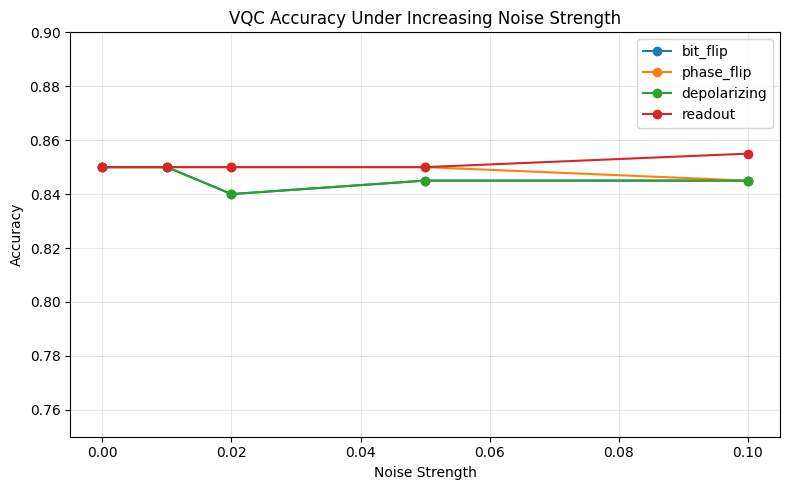

Saved: C:\Users\heart\quantum_6g_ai\results\figures\noise_robustness_accuracy_curve.png
Validation: PASS


In [12]:
# ============================================================
# CELL 9A — ACCURACY ROBUSTNESS CURVE
# ============================================================

fig, ax = plt.subplots(figsize=(8, 5))

for noise_name in NOISE_MODELS:

    subset = sweep_results[
        sweep_results["noise_model"] == noise_name
    ]

    ax.plot(
        subset["noise_strength"],
        subset["accuracy"],
        marker="o",
        label=noise_name
    )

ax.set_title(
    "VQC Accuracy Under Increasing Noise Strength"
)

ax.set_xlabel("Noise Strength")
ax.set_ylabel("Accuracy")

ax.set_ylim(0.75, 0.90)
ax.grid(True, alpha=0.3)
ax.legend()

fig.tight_layout()

accuracy_curve_path = (
    FIGURES_DIR /
    "noise_robustness_accuracy_curve.png"
)

fig.savefig(
    accuracy_curve_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

assert accuracy_curve_path.exists()

print(
    "Saved:",
    accuracy_curve_path
)

print("Validation: PASS")

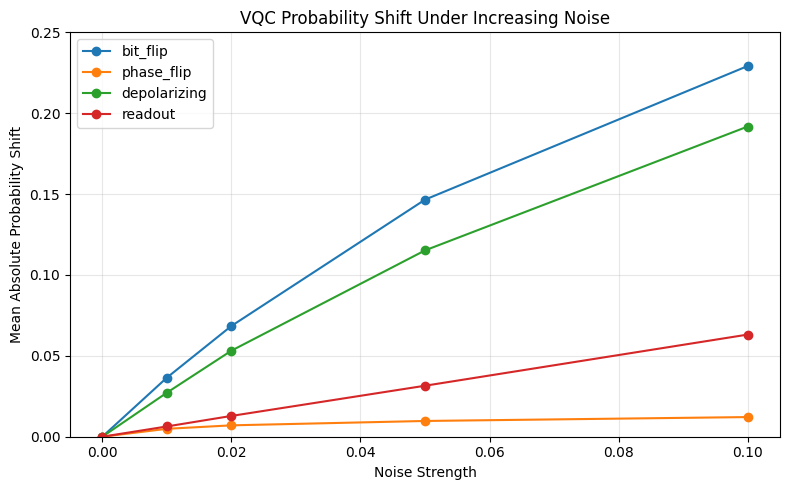

Saved: C:\Users\heart\quantum_6g_ai\results\figures\noise_robustness_probability_shift_curve.png
Validation: PASS


In [13]:
# ============================================================
# CELL 9B — PROBABILITY SHIFT ROBUSTNESS CURVE
# ============================================================

fig, ax = plt.subplots(figsize=(8, 5))

for noise_name in NOISE_MODELS:

    subset = sweep_results[
        sweep_results["noise_model"] == noise_name
    ]

    ax.plot(
        subset["noise_strength"],
        subset[
            "mean_absolute_probability_shift"
        ],
        marker="o",
        label=noise_name
    )

ax.set_title(
    "VQC Probability Shift Under Increasing Noise"
)

ax.set_xlabel("Noise Strength")
ax.set_ylabel(
    "Mean Absolute Probability Shift"
)

ax.set_ylim(
    0.0,
    max(
        0.25,
        sweep_results[
            "mean_absolute_probability_shift"
        ].max() + 0.02
    )
)

ax.grid(True, alpha=0.3)
ax.legend()

fig.tight_layout()

probability_curve_path = (
    FIGURES_DIR /
    "noise_robustness_probability_shift_curve.png"
)

fig.savefig(
    probability_curve_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

assert probability_curve_path.exists()

print(
    "Saved:",
    probability_curve_path
)

print("Validation: PASS")

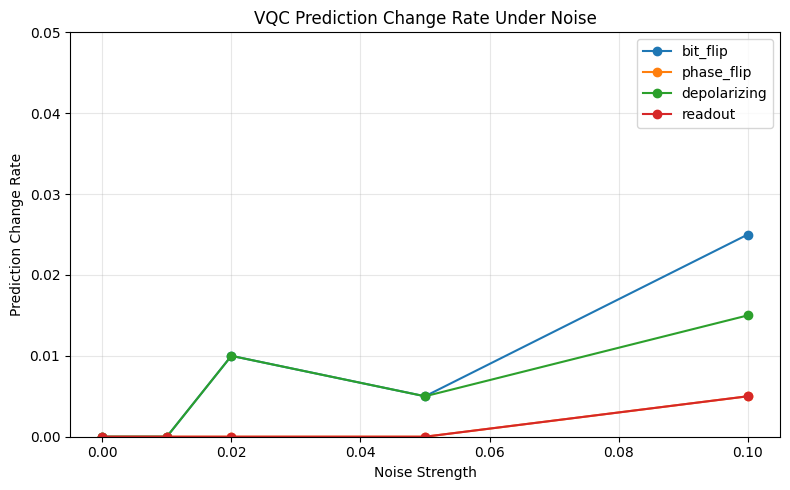

Saved: C:\Users\heart\quantum_6g_ai\results\figures\noise_robustness_prediction_change_curve.png
Validation: PASS


In [14]:
# ============================================================
# CELL 9C — PREDICTION CHANGE ROBUSTNESS CURVE
# ============================================================

fig, ax = plt.subplots(figsize=(8, 5))

for noise_name in NOISE_MODELS:

    subset = sweep_results[
        sweep_results["noise_model"] == noise_name
    ]

    ax.plot(
        subset["noise_strength"],
        subset["prediction_change_rate"],
        marker="o",
        label=noise_name
    )

ax.set_title(
    "VQC Prediction Change Rate Under Noise"
)

ax.set_xlabel("Noise Strength")
ax.set_ylabel(
    "Prediction Change Rate"
)

ax.set_ylim(
    0.0,
    max(
        0.05,
        sweep_results[
            "prediction_change_rate"
        ].max() + 0.01
    )
)

ax.grid(True, alpha=0.3)
ax.legend()

fig.tight_layout()

prediction_curve_path = (
    FIGURES_DIR /
    "noise_robustness_prediction_change_curve.png"
)

fig.savefig(
    prediction_curve_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

assert prediction_curve_path.exists()

print(
    "Saved:",
    prediction_curve_path
)

print("Validation: PASS")

In [15]:
# ============================================================
# CELL 10 — FINAL VALIDATION
# ============================================================

print("=" * 70)
print("08 — NOISE ROBUSTNESS SWEEP FINAL VALIDATION")
print("=" * 70)

# ------------------------------------------------------------
# 1. Required files
# ------------------------------------------------------------

required_files = [
    RESULTS_DIR / "noise_robustness_sweep.csv",
    RESULTS_DIR / "noise_single_sample_sweep.csv",

    FIGURES_DIR / "noise_robustness_accuracy_curve.png",
    FIGURES_DIR / "noise_robustness_probability_shift_curve.png",
    FIGURES_DIR / "noise_robustness_prediction_change_curve.png",
]

print("\nFILE VALIDATION")

for path in required_files:
    status = "PASS" if path.exists() else "FAIL"
    print(f"{status:5s} | {path}")

    assert path.exists()


# ------------------------------------------------------------
# 2. Dataset validation
# ------------------------------------------------------------

print("\nDATASET VALIDATION")

assert len(sweep_results) == 20
assert len(single_sample_results) == 20

assert sweep_results["noise_model"].nunique() == 4
assert sweep_results["noise_strength"].nunique() == 5

assert set(NOISE_MODELS) == set(
    sweep_results["noise_model"].unique()
)

expected_strengths = {
    0.00,
    0.01,
    0.02,
    0.05,
    0.10
}

assert set(
    sweep_results["noise_strength"].unique()
) == expected_strengths

print("Rows                :", len(sweep_results))
print("Noise models        :", sweep_results["noise_model"].nunique())
print("Noise strengths     :", sweep_results["noise_strength"].nunique())
print("Validation          : PASS")


# ------------------------------------------------------------
# 3. Metric validation
# ------------------------------------------------------------

print("\nMETRIC VALIDATION")

metric_columns = [
    "accuracy",
    "error_rate",
    "precision",
    "recall",
    "f1_score",
    "mean_probability_shift",
    "mean_absolute_probability_shift",
    "max_absolute_probability_shift",
    "prediction_change_rate",
]

for column in metric_columns:
    assert column in sweep_results.columns
    assert sweep_results[column].notna().all()

assert (
    (sweep_results["accuracy"] >= 0.0) &
    (sweep_results["accuracy"] <= 1.0)
).all()

assert (
    (sweep_results["error_rate"] >= 0.0) &
    (sweep_results["error_rate"] <= 1.0)
).all()

assert (
    (sweep_results["prediction_change_rate"] >= 0.0) &
    (sweep_results["prediction_change_rate"] <= 1.0)
).all()

assert (
    sweep_results["mean_absolute_probability_shift"] >= 0.0
).all()

assert (
    sweep_results["max_absolute_probability_shift"] >= 0.0
).all()

print("All metrics valid   : PASS")


# ------------------------------------------------------------
# 4. Compact robustness table
# ------------------------------------------------------------

print("\nROBUSTNESS SUMMARY @ NOISE STRENGTH = 0.10")
print("-" * 100)

summary_010 = sweep_results[
    sweep_results["noise_strength"] == 0.10
][[
    "noise_model",
    "accuracy",
    "mean_absolute_probability_shift",
    "prediction_change_rate",
]]

print(
    summary_010.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


# ------------------------------------------------------------
# 5. Baseline comparison
# ------------------------------------------------------------

ideal_accuracy = sweep_results[
    (sweep_results["noise_model"] == "bit_flip") &
    (sweep_results["noise_strength"] == 0.00)
]["accuracy"].iloc[0]

print("\nIDEAL BASELINE ACCURACY :", f"{ideal_accuracy:.6f}")

assert abs(ideal_accuracy - 0.85) < 1e-12


# ------------------------------------------------------------
# 6. Final status
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("08 NOISE ROBUSTNESS SWEEP")
print("STATUS: COMPLETE")
print("=" * 70)

08 — NOISE ROBUSTNESS SWEEP FINAL VALIDATION

FILE VALIDATION
PASS  | C:\Users\heart\quantum_6g_ai\results\noise_robustness_sweep.csv
PASS  | C:\Users\heart\quantum_6g_ai\results\noise_single_sample_sweep.csv
PASS  | C:\Users\heart\quantum_6g_ai\results\figures\noise_robustness_accuracy_curve.png
PASS  | C:\Users\heart\quantum_6g_ai\results\figures\noise_robustness_probability_shift_curve.png
PASS  | C:\Users\heart\quantum_6g_ai\results\figures\noise_robustness_prediction_change_curve.png

DATASET VALIDATION
Rows                : 20
Noise models        : 4
Noise strengths     : 5
Validation          : PASS

METRIC VALIDATION
All metrics valid   : PASS

ROBUSTNESS SUMMARY @ NOISE STRENGTH = 0.10
----------------------------------------------------------------------------------------------------
 noise_model  accuracy  mean_absolute_probability_shift  prediction_change_rate
    bit_flip  0.845000                         0.229185                0.025000
  phase_flip  0.845000             